In [1]:
RECOMPUTE = True
RECOMPUTE = False
datetag = '2026-04-14'
print(f"datetag = '{datetag}'")

datetag = '2026-04-14'


In [2]:
# %pip install -U -r ../requirements.txt

In [3]:
print('Files in that folder')
%ls -ltra
%ls -ltra cached_data

Files in that folder
total 10240
-rw-r--r--   1 laurentperrinet  staff   32146  2 nov.   2023 splncs04.bst
-rw-r--r--   1 laurentperrinet  staff     573  2 nov.   2023 readme.txt
-rw-r--r--   1 laurentperrinet  staff    1556  8 mars  09:43 Makefile
-rw-r--r--@  1 laurentperrinet  staff   11446 26 mars  19:51 airov26.sty
-rw-r--r--@  1 laurentperrinet  staff   59087 28 mars  11:35 unrolled.pdf
drwxr-xr-x  22 laurentperrinet  staff     704 28 mars  13:10 ../
-rw-r--r--@  1 laurentperrinet  staff  138167 28 mars  18:27 unrolled.svg
-rw-r--r--@  1 laurentperrinet  staff   33735 29 mars  22:00 pattern.svg
-rw-r--r--@  1 laurentperrinet  staff   36520 29 mars  22:00 target.svg
-rw-r--r--@  1 laurentperrinet  staff   65558 30 mars  17:44 izhikevich_rec.pdf
-rw-r--r--@  1 laurentperrinet  staff   86884 30 mars  17:44 izhikevich_rec.svg
-rw-r--r--@  1 laurentperrinet  staff   10556 30 mars  21:35 pattern.pdf
-rw-r--r--@  1 laurentperrinet  staff   11762 30 mars  21:35 target.pdf
-rw-r--r--@  1 

# HD-SNN: Accurate detection of spiking motifs using snnTorch



In [4]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import LambdaLR
from collections import OrderedDict
torch.set_float32_matmul_precision("medium")
torch.set_default_dtype(torch.float32)
torch.set_printoptions(precision=3, linewidth=140, sci_mode=False)
torch.autograd.set_detect_anomaly(True) # to DEBUG

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
# device = torch.device('cpu') # uncomment to force CPU usage
device

device(type='mps')

In [5]:
import snntorch as snn
# from snntorch import surrogate
import snntorch.surrogate as surrogate

# from snntorch import functional as SF
from snntorch import utils as snn_utils
import snntorch.spikeplot as splt
print('SNNtorch version', snn.__version__)
i_SM = 0

SNNtorch version 0.9.4


## handling figures

In [ ]:
import os
import numpy as np
phi = np.sqrt(5)/2 + 1/2
import matplotlib
# matplotlib.use('Agg')      # head‑less, file‑only
import matplotlib.pyplot as plt

import matplotlib
from matplotlib.figure import SubplotParams

subplotpars = SubplotParams(left=0.125, right=.95, bottom=0.25, top=.975, wspace=0.05, hspace=0.05,)
 
from pathlib import Path
data_cache = Path('cached_data')
data_cache.mkdir(exist_ok=True)

figpath = None
figpath = Path('figures')

if figpath is not None: 
    figpath.mkdir(exist_ok=True)
    def printfig(fig, name, fig_width, fig_height=None, exts=['pdf', 'png', 'svg'], figpath=figpath, dpi_exp=None, bbox='tight', verbose=True):
        if fig_height is None: fig_height = fig_width/phi
        cm = 1/2.54  # centimeters in inches
        fig.set_size_inches((fig_width*cm, fig_height*cm))  # Same as above
        for ext in exts:
            filename = figpath / f'{name}.{ext}'
            if verbose: print(f'Saving as {filename}')
            fig.savefig(filename, dpi=dpi_exp, bbox_inches=bbox, transparent=True)

## parameters

In [7]:
# https://docs.python.org/3/library/dataclasses.html?highlight=dataclass#module-dataclasses
from dataclasses import dataclass, asdict, field

@dataclass
class Params:
    datetag: str = datetag

    N_neuron: int = 512 # number of presynaptic inputs
    num_delay: int = 41 # number of timesteps in SM, must be a odd number for convolutions
    N_SM: int = 16 # number of spiking motifs
    ## Raster plots
    N_time: int =  1000 # number of timebins for the WM patterns
    N_pretime: int =  50 # number of timebins for spontaneous activity before and after the stimulus
    # p_A: float = .00016 # prior probability of firing for postsynaptic raster plot (spike per timebin)
    p_A: float = .002 # prior probability of firing for postsynaptic raster plot (spike per timebin)
    seed: int = 2018 # seed
    device = device

    # network
    lif_beta: float = .8
    # learn_beta: bool = True
    learn_beta: bool = False
    learn_threshold: bool = False
    # learn_threshold: bool = True
    do_deconv: bool = False
    
    # learning
    num_epochs: int = 16 #2**6
    num_warmup_epochs: int = 16 # 2**4
    base_lr: float = 1.0e-3
    final_lr: float = 100.e-6
    delta1: float = 10.e-3
    delta2: float =  50.e-6
    weight_decay: float = 1.e-910
    init_gain: float = 1.5
    dropout: float = 0.37
    alpha_surrogate: float = 15.
    surrogate_name: str = "FastSigmoid"
    loss_name: str = "SpikeF1scoreLoss"
    reset_mechanism: str = "subtract" # "zero" # 
    optimizer: str = 'sgd'


    ## figures
    verbose: bool = False # Displays more verbose output.
    fig_width: float = 12 # width of figure
    phi: float = 1.61803 # beauty is gold
    N_time_show: int = 400 # number of SM to show in plot_SM
    N_neuron_show: int = 256 # number of SM to show in plot_SM

    def __post_init__(self):
        torch.manual_seed(self.seed)
        np.random.seed(self.seed)


In [8]:
opt = Params()
opt

Params(datetag='2026-04-14', N_neuron=512, num_delay=41, N_SM=16, N_time=1000, N_pretime=50, p_A=0.002, seed=2018, lif_beta=0.8, learn_beta=False, learn_threshold=False, do_deconv=False, num_epochs=16, num_warmup_epochs=16, base_lr=0.001, final_lr=0.0001, delta1=0.01, delta2=5e-05, weight_decay=0.0, init_gain=1.5, dropout=0.37, alpha_surrogate=15.0, surrogate_name='FastSigmoid', loss_name='SpikeF1scoreLoss', reset_mechanism='subtract', optimizer='sgd', verbose=False, fig_width=12, phi=1.61803, N_time_show=400, N_neuron_show=256)

In [9]:
print(f'Spikes in one target {opt.p_A * opt.N_neuron * opt.N_time:.1f},  in a SM window {opt.p_A * opt.N_neuron * opt.num_delay:.1f}')

Spikes in one target 1024.0,  in a SM window 42.0


In [10]:
print(f'for a value {opt.lif_beta=:.1f}, the time constant is {- 1 / np.log(opt.lif_beta):.1f} steps')

for a value opt.lif_beta=0.8, the time constant is 4.5 steps


## compute scores

In [11]:
def get_scores(pred, target, epsilon=1e-12):
    TP = (pred * target).sum() # Count elements where both are 1
    FP = (pred * (1 - target)).sum() # Count elements where pred is 1, target is 0
    FN = ((1-pred) * target).sum()  # Count elements where pred is 0, target is 1
    precision = TP / (TP + FP + epsilon) # when minimizing false positives is critical 
    recall = TP / (TP + FN + epsilon) # when minimizing false negatives is critical 
    f1_score = 2 * (precision * recall) / (precision + recall + epsilon)
    return precision, recall, f1_score

def get_f1score(pred, target, epsilon=1e-12):
    _, _, f1_score = get_scores(pred, target, epsilon=epsilon)
    return f1_score

class SpikeF1scoreLoss(nn.Module):
    # https://en.wikipedia.org/wiki/Dice-Sørensen_coefficient
    def __init__(self, epsilon=1e-12):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, pred, target):
        f1_score =  get_f1score(pred, target, self.epsilon)
        return 1-f1_score
loss_fn = SpikeF1scoreLoss()

# print(f'Initial loss : {loss_fn(spikes.to(device), a_sample.to(device)).item():.3f}')

# SnnTorch model

In [12]:
def get_cosine_schedule_with_warmup(optimizer, num_warmup_epochs, num_epochs, rel_final_lr):
    def lr_lambda(current_epoch):
        if current_epoch < num_warmup_epochs:
            # Constant warmup of 1
            return 1
        else:
            # Cosine decay from base_lr to final_lr
            progress = (current_epoch - num_warmup_epochs) / max(1, num_epochs - num_warmup_epochs)
            cosine_decay = 0.5 * (1 + np.cos(np.pi * progress)) # from 1 to zero
            return (cosine_decay + rel_final_lr) / (1 + rel_final_lr) # between 1 and down to rel_final_lr

    scheduler = LambdaLR(optimizer, lr_lambda, last_epoch=-1)
    return scheduler

In [13]:
class HD_SNN(nn.Module):
    def __init__(self, opt):
        super().__init__()
        self.opt = opt
        # self.env = ABCD(opt)
        # self.logit_A = self.env.model_a_logit().to(self.opt.device)
        target_generator = torch.Generator()
        target_generator.manual_seed(opt.seed)
        p_bias = opt.p_A * torch.ones((opt.N_SM, opt.N_neuron, opt.N_time))
        self.target = torch.bernoulli(p_bias, generator=target_generator)
        self.target = self.target.float()
        self.target = self.target.to(opt.device)

        dropout = nn.Dropout(opt.dropout)

        lin = nn.Linear(opt.num_delay*opt.N_neuron, opt.N_neuron, bias=False)
        if self.opt.surrogate_name == 'FastSigmoid':
            spike_grad = surrogate.fast_sigmoid(slope=opt.alpha_surrogate)
        elif self.opt.surrogate_name == 'LeakySpikeOperator':
            spike_grad = surrogate.LSO(slope=opt.alpha_surrogate)
        elif self.opt.surrogate_name == 'ATan':
            spike_grad = surrogate.atan(alpha=opt.alpha_surrogate)
        elif self.opt.surrogate_name == 'SpikeRateEscape':
            spike_grad = surrogate.spike_rate_escape(slope=opt.alpha_surrogate)
        elif self.opt.surrogate_name == 'Sigmoid':
            spike_grad = surrogate.sigmoid(slope=opt.alpha_surrogate)


        lif = snn.Leaky(beta=opt.lif_beta, 
                        learn_beta=opt.learn_beta, learn_threshold=opt.learn_threshold, output=False, # init_hidden=True, 
                        reset_mechanism=opt.reset_mechanism, spike_grad=spike_grad)


        net = nn.Sequential(OrderedDict([('dropout', dropout), ('lin', lin), ('lif', lif) ]))
        net = net.to(opt.device)
        self.net = net
          
    def forward_pass(self, input_spikes):
        input_spikes = input_spikes.to(self.opt.device).detach()
        assert not input_spikes.requires_grad, "input_spikes still requires grad!"

        with torch.no_grad():
            snn_utils.reset(self.net)

        device, dtype = self.opt.device, torch.float32

        N_time = self.opt.N_time+2*self.opt.N_pretime
        current = torch.zeros(self.opt.N_SM, self.opt.N_neuron, N_time, device=device, dtype=dtype)
        spikes  = torch.zeros(self.opt.N_SM, self.opt.N_neuron, N_time, device=device, dtype=dtype)
        mem_rec = torch.zeros(self.opt.N_SM, self.opt.N_neuron, N_time, device=device, dtype=dtype)
        # Initalize membrane potential
        mem = self.net.lif.init_leaky() # pyright: ignore[reportCallIssue, reportAttributeAccessIssue]

        for t in range(self.opt.num_delay, N_time):
            spike_window_A = spikes[:, :, (t - self.opt.num_delay):t]
            spike_window_B = input_spikes[:, :, (t - self.opt.num_delay):t]
            # print(t, spike_window_A.shape, spike_window_B.shape)
            # spike_window = torch.max(spike_window_A, spike_window_B)
            spike_window = (spike_window_A + spike_window_B).clamp(0, 1)
            # window   [N_SM, N_neuron, num_delay]  ->  [N_SM, N_neuron * num_delay]
            raveled_spks = spike_window.reshape(self.opt.N_SM, self.opt.N_neuron * self.opt.num_delay)
            cur = self.net.lin(raveled_spks)                     # pyright: ignore[reportCallIssue] # shape [1, N_neuron]
            cur = self.net.dropout(cur) # pyright: ignore[reportCallIssue]

            spk, mem = self.net.lif(cur, mem)          # pyright: ignore[reportCallIssue] # spk, mem shape [1, N_neuron]
            
            current[:, :, t] = cur
            spikes[:, :, t] = spk
            mem_rec[:, :, t] = mem

        return current, mem_rec, spikes

    def update_weight(self):
        with torch.no_grad():
            # Collect all context-target pairs - see `2026-04-08_MNESIS_mulltiPC` for details
            windows = self.target[:, :, :-1].unfold(dimension=2, size=self.opt.num_delay, step=1)
            windows = windows.permute(0, 2, 1, 3).contiguous()
            batch =  self.opt.N_SM * (self.opt.N_time - self.opt.num_delay)
            contexts = windows.reshape(batch,  self.opt.N_neuron *  self.opt.num_delay)
            if self.opt.do_deconv:
                deconvolved_target = self.target - self.opt.lif_beta * torch.roll(self.target, 1, dims=-1)
                targets = deconvolved_target[:, :,  self.opt.num_delay:]             # shape (N_time-num_delay, N_SM, N_neuron)
            else:
                targets = self.target[:, :,  self.opt.num_delay:]             # shape (N_time-num_delay, N_SM, N_neuron)
            targets = targets.permute(0, 2, 1)       # (N_SM, N_time-num_delay, N_neuron)
            targets = targets.reshape(batch, self.opt.N_neuron)

            # Compute pseudo-inverse: W = (X^T X)^(-1) X^T Y
            X_pinv = torch.linalg.pinv(contexts)  # [N_neuron * num_delay, total_samples]
            W_flat = torch.matmul(X_pinv, targets)  # [N_neuron * num_delay, N_neuron]
            
            # Transpose to get [N_neuron, N_neuron * num_delay]
            W_flat = W_flat.transpose(0, 1)
            
            # Copy to network weights
            self.net.lin.weight.copy_(self.opt.init_gain * W_flat) # pyright: ignore[reportCallIssue, reportAttributeAccessIssue]

    def get_input_spikes(self):
        # clamp spikes to start the chain
        # 1/ empty spike list
        input_spikes = torch.zeros((self.opt.N_SM, self.opt.N_neuron, self.opt.N_time+2*self.opt.N_pretime))
        # 2/ spontaneous activity
        input_spikes[:, :, :self.opt.N_pretime] = torch.bernoulli(self.opt.p_A * torch.ones((self.opt.N_SM, self.opt.N_neuron, self.opt.N_pretime)))
        # 3/ target activity           
        input_spikes[:, :, self.opt.N_pretime:(self.opt.N_pretime+self.opt.num_delay)] = self.target[:, :, :self.opt.num_delay]

        return input_spikes.to(self.opt.device).detach()

    def learn_model(self, verbose=True):
        
        if self.opt.loss_name == 'SpikeF1scoreLoss':
            loss_fn = SpikeF1scoreLoss()
        elif self.opt.loss_name == 'MSELoss':
            loss_fn = nn.MSELoss()

        self.net = self.net.to(device)
        
        
        optimizer_dict = dict(lr=self.opt.base_lr, weight_decay=self.opt.weight_decay)
        if self.opt.optimizer=='adam': 
            optimizer = torch.optim.Adam(self.net.parameters(), betas=(1-self.opt.delta1, 1-self.opt.delta2), **optimizer_dict)
        elif self.opt.optimizer=='adamw': 
            optimizer = torch.optim.AdamW(self.net.parameters(), betas=(1-self.opt.delta1, 1-self.opt.delta2), **optimizer_dict)
        elif self.opt.optimizer=='sparseadam': 
            optimizer = torch.optim.AdamW(self.net.parameters(), betas=(1-self.opt.delta1, 1-self.opt.delta2), **optimizer_dict)
        elif self.opt.optimizer=='sgd': 
            optimizer = torch.optim.SGD(self.net.parameters(),  momentum=1-self.opt.delta1, dampening=1-self.opt.delta2, **optimizer_dict)
        elif self.opt.optimizer=='rmsprop': 
            optimizer = torch.optim.RMSprop(self.net.parameters(), momentum=1-self.opt.delta1, alpha=1-self.opt.delta2, **optimizer_dict)
        elif self.opt.optimizer=='adadelta': 
            optimizer = torch.optim.Adadelta(self.net.parameters(), rho=1-self.opt.delta1, **optimizer_dict)
        else:
            raise(ValueError(f'Unknown optimizer {self.opt.optimizer}'))

        scheduler = get_cosine_schedule_with_warmup(optimizer,
                                                    self.opt.num_warmup_epochs, self.opt.num_epochs, self.opt.final_lr/self.opt.base_lr)

        loss_val, precision, recall, f1_score = [], [], [], []
        log_interval = max(self.opt.num_epochs // 64, 1)

        for i_step in range(self.opt.num_epochs):
            self.net.train()

            # start optimization
            optimizer.zero_grad()
            input_spikes = self.get_input_spikes().detach()
            _, _, spikes = self.forward_pass(input_spikes)
            loss_train = loss_fn(spikes[:, :, (self.opt.N_pretime+self.opt.num_delay):(-self.opt.N_pretime)], 
                                 self.target[:, :, self.opt.num_delay:])
            loss_train.backward()
            optimizer.step()
            scheduler.step()

            with torch.no_grad():
                self.net.eval()
                # draw causes (SMs) - hidden to the observer
                input_spikes = self.get_input_spikes()
                _, _, spikes = self.forward_pass(input_spikes)
                spikes_ = spikes[:, :, (self.opt.N_pretime+self.opt.num_delay):(-self.opt.N_pretime)]
                target_ = self.target[:, :, self.opt.num_delay:]
                loss_val_ = loss_fn(spikes_, target_)
                loss_val.append(loss_val_.item())
                precision_, recall_, f1_score_ = get_scores(spikes_, target_)
                precision.append(precision_.cpu()) 
                recall.append(recall_.cpu())
                f1_score.append(f1_score_.cpu())

            if verbose and ((i_step + 1) % log_interval == 0):
                print(f'Train Epoch [{i_step+1:06d}/{self.opt.num_epochs:06d}]\t| Loss = {np.mean(loss_val):.3e}\t| precision = {np.mean(precision):.3f}\t| recall = {np.mean(recall):.3f}\t| f1_score = {np.mean(f1_score):.3f}\t| ')
                loss_val, precision, recall, f1_score = [], [], [], []
                    

hd = HD_SNN(opt)

model_filename = Path(data_cache) / f"{hd.opt.datetag}_init.pth"
lock_filename = Path(data_cache) / f"{hd.opt.datetag}_init.pth.lock"
# if False:
if RECOMPUTE:
    model_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    model_state_dict = torch.load(model_filename, map_location=torch.device(hd.opt.device))
    hd.net.load_state_dict(model_state_dict)
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Model weights loaded from {model_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Model file not found: {model_filename}, intitializing the new model.")
        lock_filename.touch(exist_ok=True)
        ##################
        hd.update_weight()
        ##################
        torch.save(hd.net.state_dict(), model_filename)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Model file is locked: {lock_filename}, passing.")

Model file not found: cached_data/2026-04-14_init.pth, intitializing the new model.


/var/folders/3s/q2x8bxzj43g4rdvb2wjt67640000gq/T/ipykernel_64522/3149711543.py:89: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  X_pinv = torch.linalg.pinv(contexts)  # [N_neuron * num_delay, total_samples]


In [14]:
with torch.no_grad():
    target_blanked = torch.nn.functional.pad(hd.target, (opt.N_pretime, opt.N_pretime))
    target_blanked[:, :, (opt.N_pretime+opt.num_delay+1):] *= 0.
    input_spikes = hd.get_input_spikes()
    current, mem, spikes = hd.forward_pass(input_spikes)
current.min().item(), current.mean().item(), current.max().item()    

(-1.045514702796936, 0.0009257377241738141, 2.5329551696777344)

Saving as ../../MNESIS/figures/pattern.pdf
Saving as ../../MNESIS/figures/pattern.png
Saving as ../../MNESIS/figures/pattern.svg


(torch.Size([16, 512, 1100]), 45.0, 987.0)

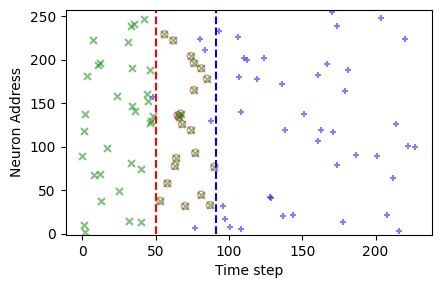

In [15]:
fig,ax = plt.subplots(figsize=(13, 8))
splt.raster(spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_blanked[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
if figpath is not None: printfig(fig, 'pattern', fig_width=opt.fig_width, fig_height=opt.fig_width/phi)
spikes.shape, spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].sum().item(), hd.target[i_SM, :, :].sum().item()

In [16]:
model_filename = Path(data_cache) / f"{hd.opt.datetag}.pth"
lock_filename = Path(data_cache) / f"{hd.opt.datetag}.pth.lock"
# if True:
if RECOMPUTE:
    model_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    model_state_dict = torch.load(model_filename, map_location=torch.device(hd.opt.device))
    hd.net.load_state_dict(model_state_dict)
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Model weights loaded from {model_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Model file not found: {model_filename}, training a new model.")
        lock_filename.touch(exist_ok=True)
        ##################        
        hd.learn_model()
        ##################        
        torch.save(hd.net.state_dict(), model_filename)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Model file is locked: {lock_filename}, passing.")

Model file not found: cached_data/2026-04-14.pth, training a new model.
Train Epoch [000001/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000002/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000003/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000004/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000005/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000006/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000007/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000008/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000009/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.

In [17]:
with torch.no_grad():
    target_full = torch.nn.functional.pad(hd.target, (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes()
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = hd.target[:, :, hd.opt.num_delay:]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

precision = 1.000	 recall = 1.000	 f1_score = 1.000 


Saving as ../../MNESIS/figures/target.pdf
Saving as ../../MNESIS/figures/target.png
Saving as ../../MNESIS/figures/target.svg


(torch.Size([16, 512, 1100]), 943.0, 987.0)

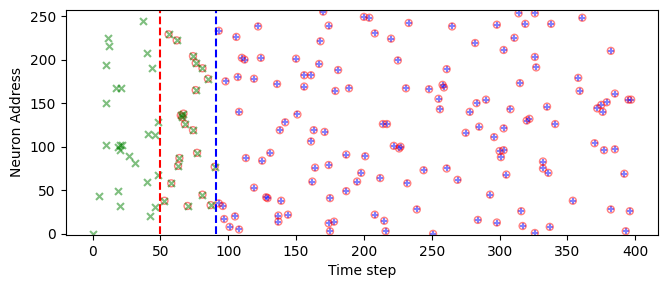

In [18]:
fig,ax = plt.subplots(figsize=(13, 8))
splt.raster(spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
if figpath is not None: printfig(fig, 'target', fig_width=opt.fig_width*phi, fig_height=opt.fig_width/phi)
spikes.shape, spikes[i_SM, :, :].sum().item(), hd.target[i_SM, :, :].sum().item()

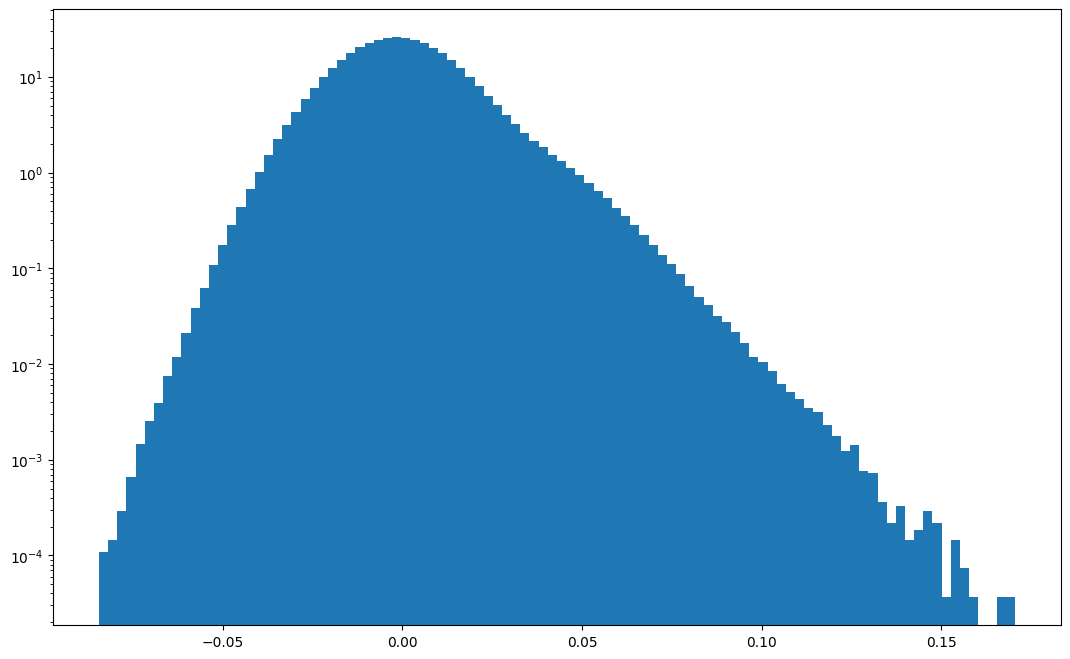

In [19]:
# hd.net.lin.bias.cpu().detach().numpy()
fig,ax = plt.subplots(figsize=(13, 8))
ax.hist(hd.net.lin.weight.cpu().detach().numpy().ravel(), bins=100, density=True) # pyright: ignore[reportCallIssue, reportAttributeAccessIssue]
ax.set_yscale('log')

### TODO : testing training - growing with num epochs


### TODO : testing inference - noise

### TODO : testing inference - initiating with half the neurons

### TODO : learning Spiking Heidelberg Digits patterns

## scanning parameters

In [ ]:
opt_scan = Params( datetag = datetag + '_scan',
                    # N_time = 2**14,
                    fig_width = 3.25,
                    )
scan_dicts= {'N_SM' : [2, 3, 5, 8, 13, 21], #, 34, 55, 89, 144, 233, 377, 610, 987, 1364, 2351
             'N_time' : [2**k for k in range(6, 12)],
             'num_delay' : [2, 3, 5, 8, 13, 21, 34, 55, 89],
             'N_neuron' : [55, 89, 144, 233, 377, 610, 987, 1364], #13, 21, 34, 
             'p_A':[0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05], #0.00001, 0.00002, 0.00005, 0.0001, .. , 0.1, 0.5
            }
label_dicts= {'N_SM' : 'number of patterns',
             'N_time' : 'Pattern duration',
             'num_delay' : 'Delay range',
             'N_neuron' : 'Presynaptic inputs',
             'p_A': 'Average firing',
            }
import os
import time
import pandas as pd
import numpy as np

N_cv = 10
N_cv = 2
verb = True

for key in scan_dicts:
    print(f"{50*'-'}\nscanning {key=}\n{50*'-'}", )
    filename = data_cache / f'{opt_scan.datetag}_{key}.json'
    lock_filename = data_cache / f'{opt_scan.datetag}_{key}.lock'
    if RECOMPUTE : 
        filename.unlink(missing_ok=True) # FORCING RECOMPUTE
        lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE

    if not lock_filename.exists():
        if filename.exists():
            df_scan = pd.read_json(filename, orient='records', indent=2)
        else:
            lock_filename.touch(exist_ok=True)
            measure_columns = [key, 'loss', 'time']
            df_scan = pd.DataFrame([], columns=measure_columns)
            i_loc = 0
            for i_value, value in enumerate(scan_dicts[key]):
                if verb: print('|', i_value + 1, '/', len(scan_dicts[key]), end='\t')

                for i_cv in  range(N_cv):
                    # tic
                    since = time.time()
                    new_dict = asdict(opt)
                    # print(key, value)
                    new_dict[key] = value
                    new_opt = Params(**new_dict)

                    new_hd = HD_SNN(new_opt)                    
                    new_hd.update_weight()
                    new_hd.learn_model(verbose=False)

                    # test it
                    with torch.no_grad():
                        input_spikes = new_hd.get_input_spikes()
                        _, _, spikes = new_hd.forward_pass(input_spikes)
                        spikes_ = spikes[:, :, (new_hd.opt.N_pretime+new_hd.opt.num_delay):(-new_hd.opt.N_pretime)]
                        target_ = new_hd.target[:, :, new_hd.opt.num_delay:]
                        loss_val = loss_fn(spikes_, target_)
                                            
                    # toc
                    elapsed_time = time.time() - since
                    df_scan.loc[i_loc] = {key:value, 'loss':loss_val.item(), 'time':elapsed_time}
                    i_loc += 1
                    if verb: 
                        print(f'|{key=}:{value=} \t| loss={loss_val.item():.3f}', end='\t')
                        print(f"| completed in {elapsed_time // 60:.1f}m {elapsed_time % 60:.1f}s |")

            df_scan.to_json(filename, orient='records', indent=2)
        lock_filename.unlink(missing_ok=True)
        # print(df_scan)


--------------------------------------------------
scanning key='N_SM'
--------------------------------------------------
| 1 / 6	|key='N_SM':value=2 	| loss=0.000	| completed in 3.0m 53.0s |
|key='N_SM':value=2 	| loss=0.000	| completed in 3.0m 52.4s |
| 2 / 6	|key='N_SM':value=3 	| loss=0.000	| completed in 3.0m 52.3s |
|key='N_SM':value=3 	| loss=0.000	| completed in 3.0m 54.3s |
| 3 / 6	|key='N_SM':value=5 	| loss=0.000	| completed in 4.0m 15.2s |
|key='N_SM':value=5 	| loss=0.000	| completed in 4.0m 18.7s |
| 4 / 6	|key='N_SM':value=8 	| loss=0.000	| completed in 5.0m 23.0s |
|key='N_SM':value=8 	| loss=0.000	| completed in 5.0m 19.8s |
| 5 / 6	|key='N_SM':value=13 	| loss=0.000	| completed in 12.0m 7.9s |
|key='N_SM':value=13 	| loss=0.000	| completed in 13.0m 28.9s |
| 6 / 6	|key='N_SM':value=21 	| loss=0.996	| completed in 21.0m 54.0s |


In [ ]:
subplotpars_scan = SubplotParams(left=0.125, right=.95, bottom=0.25, top=.975)
custom_style = {
    'axes.spines.left': True,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.spines.bottom': True,
}

for key in scan_dicts:
    print(f"{50*'-'}\nscanning {key=}\n{50*'-'}", )
    filename = data_cache / f'{opt_scan.datetag}_{key}.json'
    print(f'Reading {filename=}...')
    df_scan = pd.read_json(filename)
    print(df_scan)
    # https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html?highlight=errorbar#visualization-errorbars
    fig, ax = plt.subplots(figsize=(opt_scan.fig_width, opt_scan.fig_width), subplotpars=subplotpars_scan)
    gp_scan = df_scan[[key, 'loss']].groupby([key])
    means = gp_scan.mean()
    errors = gp_scan.std()

    with plt.style.context(custom_style):
        means.plot.bar(yerr=errors, ax=ax, capsize=4, rot=-60, legend=False, alpha=.5)

    ax.set_ylabel('Loss')
    ax.set_xlabel(label_dicts[key])

    # ax.set_xscale('logit')
    ax.set_ylim(0, 1)
    # if key in ['p_A']:
    #     ax.ticklabel_format(style='scientific', axis='both', scilimits=(0,0))

    #fig = ax.get_figure()
    if not figpath is None: 
        printfig(fig, 'MNESIS_' + key, fig_width=opt.fig_width/2)

    pos = ax.get_position()
    print(pos)
    # plt.show()   # show then close immediately

## optimizing learning parameters with optuna

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning,)
optuna_filename = Path(data_cache) / f"{opt.datetag}_optuna.sqlite3" 
if RECOMPUTE : 
    optuna_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
# optuna_filename.unlink(missing_ok=True) # FORCING RECOMPUTE    
%ls -l {optuna_filename}


In [ ]:
def objective(trial):    
    new_opt = Params(num_epochs=200)

    new_opt.do_deconv = trial.suggest_categorical('do_deconv', [True, False])
    # new_opt.learn_beta = trial.suggest_categorical('learn_beta', [True, False])
    # new_opt.learn_threshold = trial.suggest_categorical('learn_threshold', [True, False])
    new_opt.reset_mechanism = trial.suggest_categorical('reset_mechanism', ['zero', 'subtract'])
    new_opt.optimizer = trial.suggest_categorical('optimizer', ['adamw', 'rmsprop', 'adadelta', 'sgd', 'adam']) # 'adagrad', 'sparseadam', 

    new_opt.surrogate_name = trial.suggest_categorical('surrogate_name', ['FastSigmoid', 'LeakySpikeOperator', 'ATan', 'Sigmoid', 'SpikeRateEscape'])
    new_opt.loss_name = trial.suggest_categorical('loss_name', [  'SpikeF1scoreLoss', 'MSELoss'])

    new_opt.lif_beta = trial.suggest_float('lif_beta', 0, 1)
    scale = 10
    scale = 3.618    
    new_opt.alpha_surrogate = trial.suggest_float('alpha_surrogate', new_opt.alpha_surrogate / scale, new_opt.alpha_surrogate * scale, log=True)
    new_opt.base_lr = trial.suggest_float('base_lr', new_opt.base_lr / scale, new_opt.base_lr * scale, log=True)
    new_opt.final_lr = trial.suggest_float('final_lr', new_opt.final_lr / scale, new_opt.final_lr * scale, log=True)
    new_opt.delta1 = trial.suggest_float('delta1', new_opt.delta1 / scale, min((new_opt.delta1 * scale, .99)), log=True)
    new_opt.delta2 = trial.suggest_float('delta2', new_opt.delta2 / scale, min((new_opt.delta2 * scale, .99)), log=True)
    new_opt.weight_decay = trial.suggest_float('weight_decay', new_opt.weight_decay / scale, new_opt.weight_decay * scale, log=True)
    new_opt.dropout = trial.suggest_float('dropout', 0, 1)
    new_opt.init_gain = trial.suggest_float('init_gain', new_opt.init_gain / scale, new_opt.init_gain * scale, log=True)

    try:
        hd = HD_SNN(new_opt)
        hd.update_weight()
        hd.learn_model(verbose=False)
        
        with torch.no_grad():
            # draw causes (SMs) - hidden to the observer
            input_spikes = hd.get_input_spikes()
            _, _, spikes = hd.forward_pass(input_spikes)
            spikes_ = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
            target_ = hd.target[:, :, hd.opt.num_delay:]
            loss_val = loss_fn(spikes_, target_)

        return loss_val.item()
    except:
        return 1.
        
total_trials = 300

# 3. Create a study object and optimize the objective function.
study = optuna.create_study(
    storage=f"sqlite:///{str(optuna_filename)}",
    sampler=optuna.samplers.TPESampler(multivariate=True, warn_independent_sampling=False),
    direction="minimize",
    load_if_exists=True,
    study_name=opt.datetag,
)

if len(study.trials)>0:
    print("So far, Best params: ", study.best_params, end=', ')
    print("Best value: ", study.best_value)

print(
    f"Starting optimization on {max(total_trials - len(study.trials), 0)} trials with {len(study.trials)} existing trials."
)
study.optimize(objective, n_trials=max((total_trials - len(study.trials), 0)), n_jobs=1, show_progress_bar=True)


In [ ]:
study = optuna.load_study(storage=f"sqlite:///{str(optuna_filename)}", study_name=opt.datetag)

In [ ]:
print(50 * "-.")
print("Best params: ", study.best_params)
print("Best value: ", study.best_value)
# print("Best Trial params: ", study.best_trial.params)

In [ ]:
torch.linspace(-0.5, 0.5, 2)

In [ ]:
import optuna.visualization.matplotlib as vis
vis.plot_param_importances(study)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import numpy as np
import pandas as pd

# Charger l'étude
params = sorted({k for t in study.trials for k in t.params})

fig, axes = plt.subplots(len(params), 1, figsize=(15, 8 * len(params)), sharey=True)

for ax, pname in zip(axes, params):
    xs = [t.params[pname] for t in study.trials if pname in t.params]
    ys = [t.value for t in study.trials if pname in t.params]

    # Créer un DataFrame pour faciliter la manipulation
    df = pd.DataFrame({"x": xs, "y": ys})
    # Déterminer si le paramètre est numérique (et non catégoriel)
    is_numeric = pd.api.types.is_numeric_dtype(df["x"])
    if is_numeric:
        # Si numérique, vérifier s'il y a assez de valeurs distinctes pour LOWESS
        if len(df["x"].unique()) > 1:
            sns.regplot(
                x="x", y="y", data=df, ax=ax, lowess=True, color="red",
                line_kws={"lw": 2, "label": "Tendance (LOWESS)"}, scatter=False
            )
    else:
        # Pour les catégories, convertir en chaîne et afficher un boxplot
        df["x"] = df["x"].astype(str)
    #     sns.boxplot(x="x", y="y", data=df, ax=ax, color="lightblue", width=0.5)

    # Toujours afficher les points bruts
    ax.scatter(df["x"], df["y"], s=20, alpha=0.7, color="blue", label="Trials")

    ax.set_xlabel(pname)
    ax.set_ylabel("Objective")
    ax.set_yscale("log")
    if pname not in ['learn_beta', 'learn_threshold', 'optimizer', 'reset_mechanism'] :
        ax.set_xscale("log")

    # ax.legend()

plt.tight_layout()